# QQQ Opening Range Bias — analysis notebook (v2)

Narrative walkthrough built on the tested `qqq_opening_bias` package. Every number
here is also reproducible non-interactively with:

```bash
python scripts/run_analysis.py --qqq data/QQQ_5min_10years_UTC.csv --nq data/nq-10y-1min.csv
```

⚠️ Requires the two CSVs in `../data/` (schema in `data/README.md`). Run top-to-bottom.

In [1]:
import sys; sys.path.insert(0, "../src")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from qqq_opening_bias import (
    BacktestConfig, run_backtest, run_placebo,
    load_qqq_bars, load_nq_bars,
    equity_series, compute_performance,
    per_trade_t_test, bootstrap_sharpe_ci, yearly_breakdown,
    slippage_sensitivity, equity_curves,
)

COMMISSION = 0.0005
SLIP = dict(entry_slippage_per_share=0.02, additional_stop_slippage_per_share=0.04)
BASE = dict(commission_per_share_per_side=COMMISSION)

## 1 · Load data
The replication runs on the full set of complete QQQ sessions — it is *not* pre-intersected with NQ, so the paper's ~1,795 trade count is recovered.

In [2]:
qqq = load_qqq_bars("../data/QQQ_5min_10years_UTC.csv")
nq  = load_nq_bars("../data/nq-10y-1min.csv")
trading_dates = pd.to_datetime(qqq["date"]).dt.normalize().unique()
print(f"QQQ bars: {len(qqq):,}   NQ bars: {len(nq):,}   sessions: {len(trading_dates):,}")

QQQ bars: 141,805   NQ bars: 141,299   sessions: 1,795


## 2 · Scenarios

| scenario | costs | confirmation |
|---|---|---|
| replication | commission only | — |
| slippage | + $0.02 / $0.04 | — |
| NQ filter | + slippage | NQ 09:25 bar |
| placebo | + slippage | QQQ **own** 09:25 bar |

The placebo is the control: if the NQ filter were just two-bar momentum, the placebo would match it.

In [3]:
results = {
    "replication": run_backtest(qqq, config=BacktestConfig(**BASE)),
    "slippage": run_backtest(qqq, config=BacktestConfig(**BASE, **SLIP)),
    "nq_filter": run_backtest(qqq, config=BacktestConfig(**BASE, require_nq_confirmation=True, **SLIP), nq_bars=nq),
    "placebo_qqq925": run_placebo(qqq, config=BacktestConfig(**BASE, **SLIP)),
}

rows = []
for name, r in results.items():
    eq = equity_series(r, trading_dates)
    perf = compute_performance(eq)
    edge = per_trade_t_test(r)
    lo, hi = bootstrap_sharpe_ci(eq)
    rows.append({"scenario": name, "trades": len(r.trades),
                 "net_pnl": round(r.cumulative_pnl),
                 "pnl_per_share": round(r.mean_pnl_per_share, 4),
                 "t_stat": round(edge.t_stat, 2), "sharpe": round(perf.sharpe, 2),
                 "sharpe_ci": f"[{lo:.2f}, {hi:.2f}]",
                 "cagr": round(perf.cagr, 3), "max_dd": round(perf.max_drawdown, 3)})
pd.DataFrame(rows).set_index("scenario")

,trades,net_pnl,pnl_per_share,t_stat,sharpe,sharpe_ci,cagr,max_dd
scenario,,,,,,,,
replication,1775,138639,0.0704,1.79,1.06,"[0.34, 1.71]",0.304,-0.224
slippage,1775,4860,0.0204,0.52,0.23,"[-0.53, 0.93]",0.027,-0.439
nq_filter,844,44332,0.1252,2.05,0.77,"[0.05, 1.41]",0.156,-0.311
placebo_qqq925,825,25191,0.0787,1.27,0.57,"[-0.17, 1.21]",0.105,-0.272


## 3 · Equity curves vs buy & hold

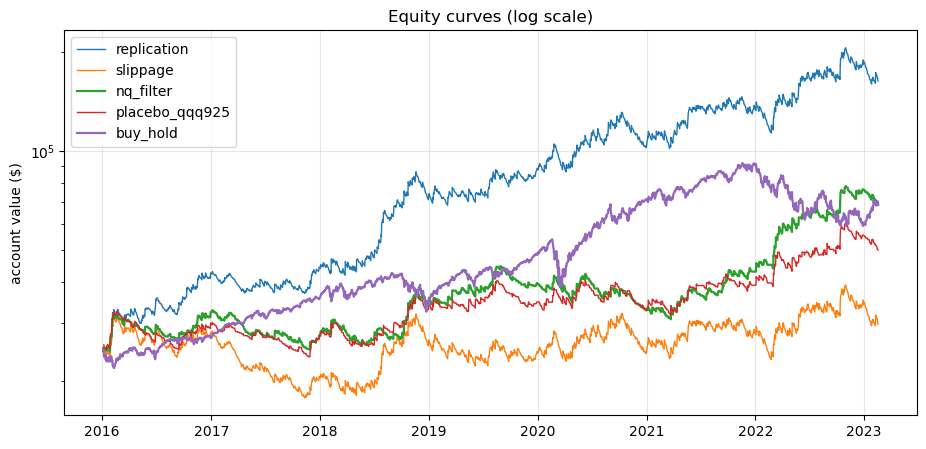

replication       163639.0
slippage           29860.0
nq_filter          69332.0
placebo_qqq925     50191.0
buy_hold           68706.0
Name: 2023-02-17 00:00:00, dtype: float64

In [4]:
curves = equity_curves(qqq, nq)
fig, ax = plt.subplots(figsize=(11, 5))
for col in curves.columns:
    ax.plot(curves.index, curves[col], label=col, lw=1.6 if col in ("nq_filter","buy_hold") else 1.0)
ax.set_yscale("log"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("Equity curves (log scale)"); ax.set_ylabel("account value ($)")
plt.show()
curves.iloc[-1].round(0)

## 4 · Per-year breakdown
If the P&L concentrates in 2022, the edge is a volatility-regime artifact, not a structural one.

In [5]:
for k in ("replication", "nq_filter"):
    print(f"— {k}")
    display(yearly_breakdown(results[k]).round(3))

— replication


,trades,net_pnl,pnl_per_share,win_rate,avg_r
year,,,,,
2016,246,17701.751,0.067,0.264,0.415
2017,244,1737.366,0.015,0.234,-0.009
2018,248,26834.215,0.128,0.246,0.279
2019,251,17604.478,0.046,0.235,0.175
2020,250,14149.402,0.006,0.224,0.108
2021,252,31430.627,0.085,0.254,0.127
2022,251,53270.909,0.209,0.243,0.139
2023,33,-24089.305,-0.426,0.091,-0.476


— nq_filter


,trades,net_pnl,pnl_per_share,win_rate,avg_r
year,,,,,
2016,113,7477.640,0.088,0.274,0.311
2017,116,-4885.189,-0.036,0.216,-0.319
2018,121,6823.044,0.143,0.240,0.175
2019,118,5374.558,0.064,0.254,0.253
2020,117,-6875.793,-0.119,0.171,-0.230
2021,119,10182.680,0.208,0.294,0.239
2022,126,33563.811,0.582,0.310,0.505
2023,14,-7328.479,-0.653,0.071,-0.760


## 5 · Slippage sensitivity
At what execution cost does the edge cross zero?

,entry_slippage,net_pnl,pnl_per_share,sharpe
0,0.000,138639.443,0.0704,1.0566
1,0.005,82012.710,0.0579,0.8490
2,0.010,44917.707,0.0454,0.6423
3,0.015,20709.038,0.0329,0.4373
4,0.020,4859.551,0.0204,0.2332
5,0.025,-5464.594,0.0079,0.0312
6,0.030,-12198.687,-0.0045,-0.1690
7,0.035,-16656.686,-0.0170,-0.3708
8,0.040,-19513.113,-0.0295,-0.5673
9,0.045,-21413.472,-0.0420,-0.7671


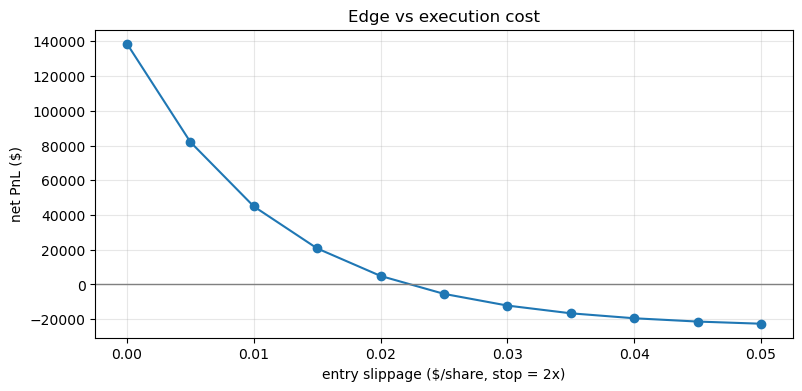

In [6]:
sens = slippage_sensitivity(qqq, base_config=BacktestConfig(**BASE))
display(sens.round(4))
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sens["entry_slippage"], sens["net_pnl"], marker="o")
ax.axhline(0, color="gray", lw=1)
ax.set_xlabel("entry slippage ($/share, stop = 2x)"); ax.set_ylabel("net PnL ($)")
ax.set_title("Edge vs execution cost"); ax.grid(alpha=0.3)
plt.show()

## 6 · Exit-reason anatomy
The +10R target is nearly decorative — most exits are stops or the session close.

In [7]:
pd.DataFrame({name: pd.Series([t.exit_reason for t in r.trades]).value_counts(normalize=True)
              for name, r in results.items()}).round(3)

,replication,slippage,nq_filter,placebo_qqq925
stop,0.749,0.749,0.743,0.752
session_close,0.226,0.226,0.225,0.219
target,0.024,0.024,0.032,0.029
